In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

C:\Users\Anamika Chauhan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully!


In [2]:
df = pd.read_csv("payment_transaction_anomaly_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,transaction_id,user_id,timestamp,amount,merchant_category,country,home_country,device_id,channel,hours_since_prev_txn,transaction_frequency_24h,avg_amount_30d,account_age_days,distance_from_home_km,new_device,is_anomaly
0,TXN000001,10907,2025-01-01 00:25:17.635131015,15.93,Grocery,India,India,DEV259876,Online,2.11,5,16.28,933,5.74,0,0
1,TXN000002,11190,2025-01-01 02:12:41.404814367,21.15,Grocery,UK,India,DEV648332,Mobile,1.75,5,22.53,904,18.65,0,0
2,TXN000003,11109,2025-01-01 02:41:23.918264513,61.77,Electronics,UK,UK,DEV393847,Mobile,7.58,2,30.94,900,92.92,0,0
3,TXN000004,10128,2025-01-01 02:42:47.705671627,24.95,Clothing,India,India,DEV604576,Mobile,15.49,3,24.49,1802,1.41,1,0
4,TXN000005,10382,2025-01-01 02:53:31.902406849,17.55,Healthcare,India,India,DEV182596,Online,2.73,0,21.00,589,65.33,0,0


In [4]:
df.shape

(10000, 16)

In [5]:
df.columns

Index(['transaction_id', 'user_id', 'timestamp', 'amount', 'merchant_category',
       'country', 'home_country', 'device_id', 'channel',
       'hours_since_prev_txn', 'transaction_frequency_24h', 'avg_amount_30d',
       'account_age_days', 'distance_from_home_km', 'new_device',
       'is_anomaly'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10000 non-null  str    
 1   user_id                    10000 non-null  int64  
 2   timestamp                  10000 non-null  str    
 3   amount                     10000 non-null  float64
 4   merchant_category          10000 non-null  str    
 5   country                    10000 non-null  str    
 6   home_country               10000 non-null  str    
 7   device_id                  10000 non-null  str    
 8   channel                    10000 non-null  str    
 9   hours_since_prev_txn       10000 non-null  float64
 10  transaction_frequency_24h  10000 non-null  int64  
 11  avg_amount_30d             10000 non-null  float64
 12  account_age_days           10000 non-null  int64  
 13  distance_from_home_km      10000 non-null  float64
 14  ne

In [7]:
df.isnull().sum()

transaction_id               0
user_id                      0
timestamp                    0
amount                       0
merchant_category            0
country                      0
home_country                 0
device_id                    0
channel                      0
hours_since_prev_txn         0
transaction_frequency_24h    0
avg_amount_30d               0
account_age_days             0
distance_from_home_km        0
new_device                   0
is_anomaly                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["is_anomaly"].value_counts()

is_anomaly
0    9490
1     510
Name: count, dtype: int64

In [11]:
df["is_anomaly"].value_counts(normalize=True) * 100

is_anomaly
0    94.9
1     5.1
Name: proportion, dtype: float64

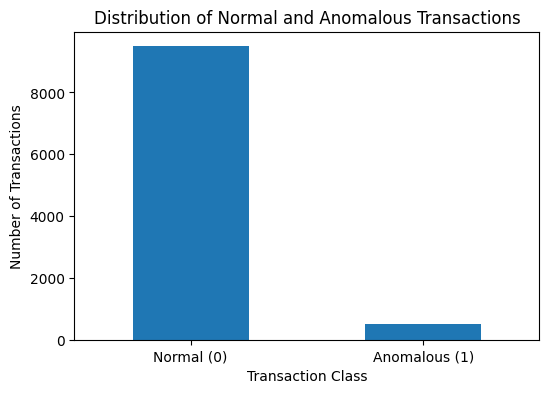

In [12]:
df["is_anomaly"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)
plt.title("Distribution of Normal and Anomalous Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks(
    [0, 1],
    ["Normal (0)", "Anomalous (1)"],
    rotation=0
)
plt.show()

In [13]:
df["amount"].describe()

count    10000.000000
mean        48.784225
std         40.193319
min          2.680000
25%         23.257500
50%         37.000000
75%         60.982500
max        496.060000
Name: amount, dtype: float64

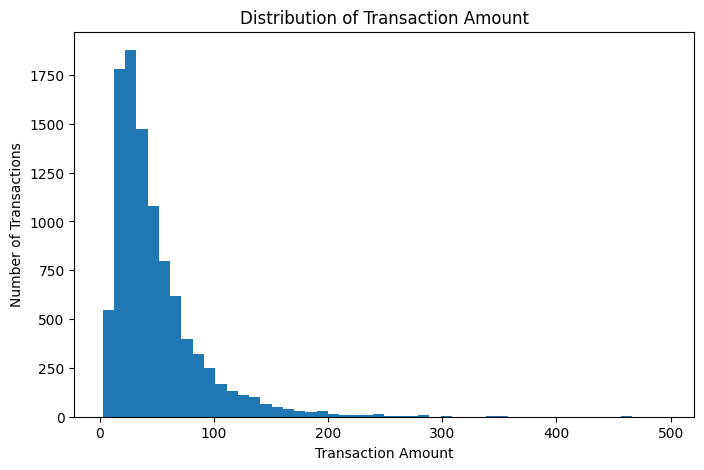

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

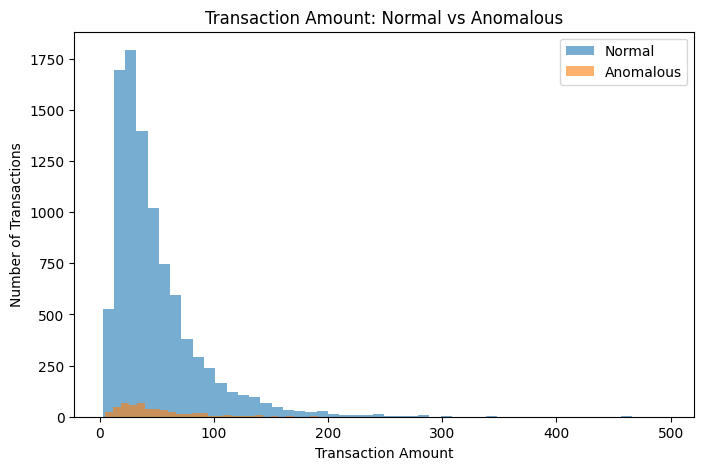

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(
    df[df["is_anomaly"] == 0]["amount"],
    bins=50,
    alpha=0.6,
    label="Normal"
)
plt.hist(
    df[df["is_anomaly"] == 1]["amount"],
    bins=50,
    alpha=0.6,
    label="Anomalous"
)
plt.title("Transaction Amount: Normal vs Anomalous")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.legend()
plt.show()

In [16]:
df.groupby("is_anomaly")["amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_anomaly,,,,,
0,9490,48.631457,36.88,2.68,496.06
1,510,51.626902,38.98,5.12,349.48


In [17]:
pd.crosstab(
    df["new_device"],
    df["is_anomaly"],
    normalize="index"
) * 100

is_anomaly,0,1
new_device,,
0,95.344713,4.655287
1,90.797546,9.202454


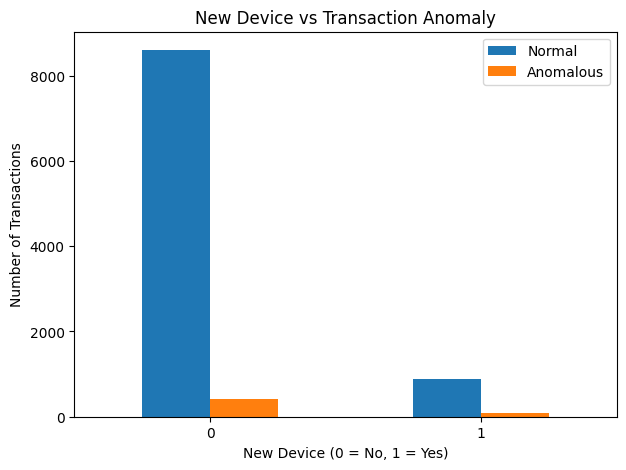

In [18]:
pd.crosstab(
    df["new_device"],
    df["is_anomaly"]
).plot(
    kind="bar",
    figsize=(7, 5)
)
plt.title("New Device vs Transaction Anomaly")
plt.xlabel("New Device (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.legend(["Normal", "Anomalous"])
plt.show()

In [19]:
df.groupby("is_anomaly")["transaction_frequency_24h"].describe()

,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
0,9490.0,2.184932,1.485393,0.0,1.0,2.0,3.0,10.0
1,510.0,2.254902,1.479966,0.0,1.0,2.0,3.0,8.0


<Figure size 800x500 with 0 Axes>

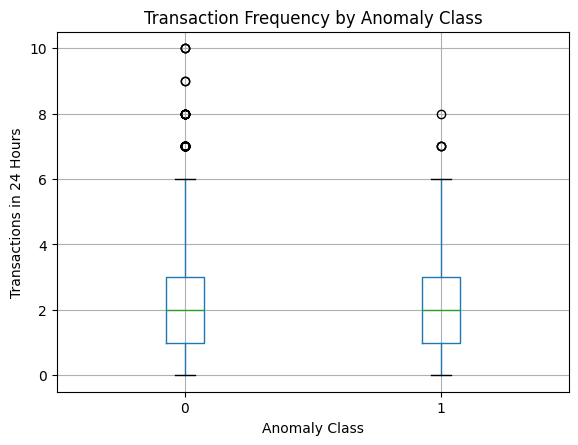

In [20]:
plt.figure(figsize=(8, 5))
df.boxplot(
    column="transaction_frequency_24h",
    by="is_anomaly"
)
plt.title("Transaction Frequency by Anomaly Class")
plt.suptitle("")
plt.xlabel("Anomaly Class")
plt.ylabel("Transactions in 24 Hours")
plt.show()

In [21]:
df.groupby("is_anomaly")["distance_from_home_km"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
is_anomaly,,,,
0,34.333870,23.765,0.00,317.67
1,37.292118,24.745,0.13,203.99


<Figure size 800x500 with 0 Axes>

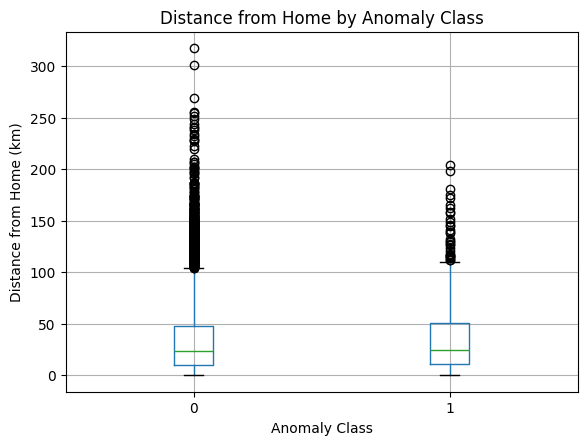

In [22]:
plt.figure(figsize=(8, 5))
df.boxplot(
    column="distance_from_home_km",
    by="is_anomaly"
)
plt.title("Distance from Home by Anomaly Class")
plt.suptitle("")
plt.xlabel("Anomaly Class")
plt.ylabel("Distance from Home (km)")
plt.show()

In [23]:
merchant_anomaly = pd.crosstab(
    df["merchant_category"],
    df["is_anomaly"]
)
merchant_anomaly

is_anomaly,0,1
merchant_category,,
Clothing,943,58
Electronics,891,42
Entertainment,959,57
Fuel,991,59
Grocery,883,46
Healthcare,971,41
Online_Shopping,950,62
Restaurant,920,49
Travel,991,45


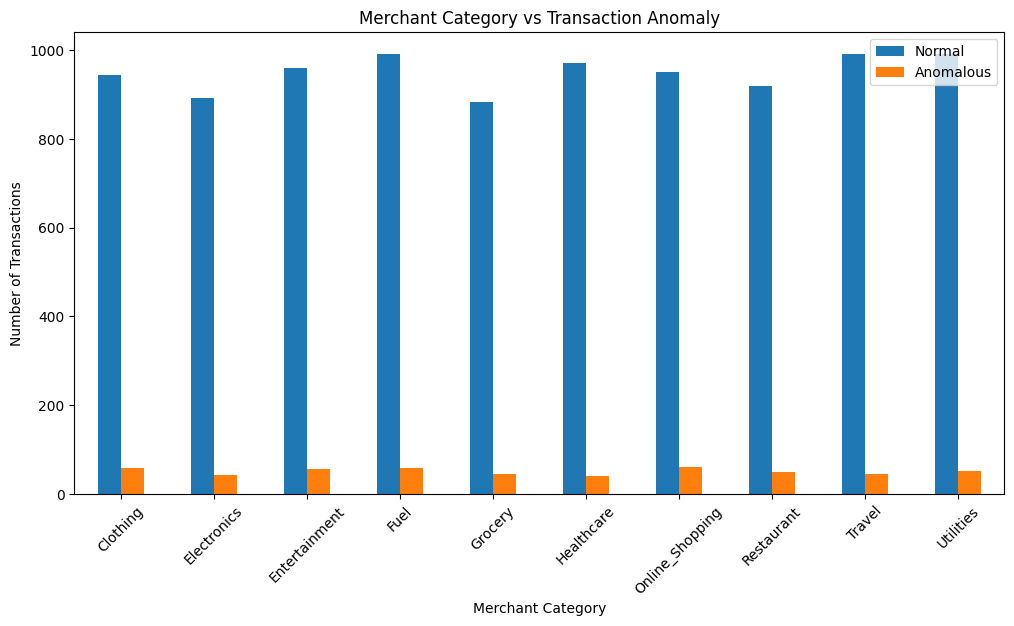

In [24]:
merchant_anomaly.plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Merchant Category vs Transaction Anomaly")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.legend(["Normal", "Anomalous"])
plt.show()

In [25]:
numeric_columns = [
    "amount",
    "hours_since_prev_txn",
    "transaction_frequency_24h",
    "avg_amount_30d",
    "account_age_days",
    "distance_from_home_km",
    "new_device",
    "is_anomaly"
]
correlation = df[numeric_columns].corr()
correlation

,amount,hours_since_prev_txn,transaction_frequency_24h,avg_amount_30d,account_age_days,distance_from_home_km,new_device,is_anomaly
amount,1.000000,0.000636,-0.001711,0.714050,0.018863,-0.003724,-0.014088,0.016396
hours_since_prev_txn,0.000636,1.000000,0.009555,-0.003416,-0.001163,0.011441,-0.000598,-0.004407
transaction_frequency_24h,-0.001711,0.009555,1.000000,-0.004975,0.009956,0.003428,-0.013682,0.010366
avg_amount_30d,0.714050,-0.003416,-0.004975,1.000000,0.020375,-0.003274,-0.007788,-0.014858
account_age_days,0.018863,-0.001163,0.009956,0.020375,1.000000,0.012908,-0.005237,0.023143
distance_from_home_km,-0.003724,0.011441,0.003428,-0.003274,0.012908,1.000000,0.004545,0.018996
new_device,-0.014088,-0.000598,-0.013682,-0.007788,-0.005237,0.004545,1.000000,0.061396
is_anomaly,0.016396,-0.004407,0.010366,-0.014858,0.023143,0.018996,0.061396,1.000000


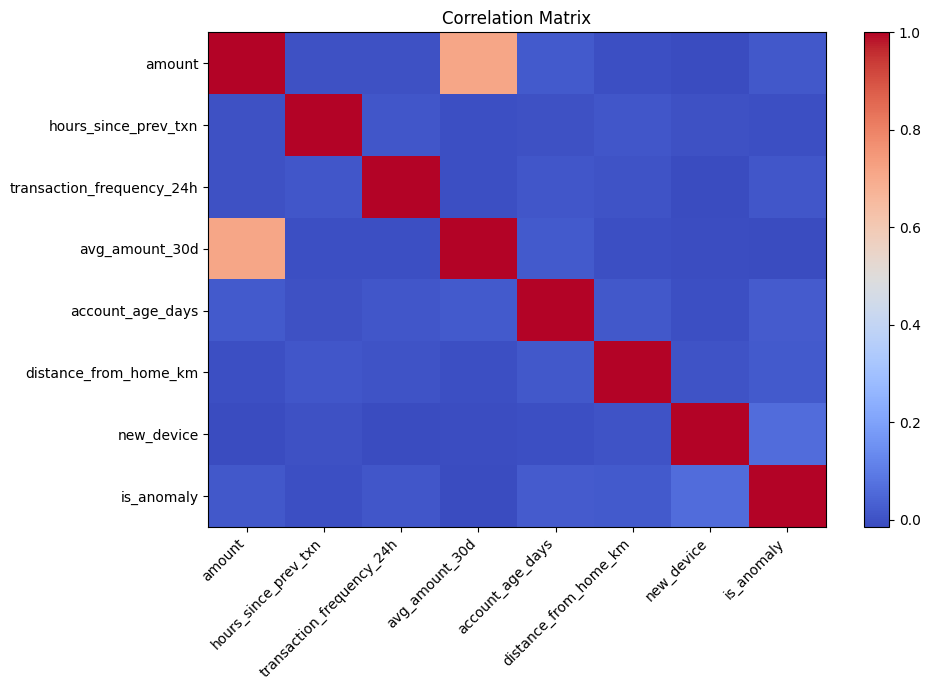

In [26]:
plt.figure(figsize=(10, 7))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

df = pd.read_csv("payment_transaction_anomaly_dataset.csv")

print(df.shape)
print(df.columns.tolist())


C:\Users\Anamika Chauhan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(10000, 16)
['transaction_id', 'user_id', 'timestamp', 'amount', 'merchant_category', 'country', 'home_country', 'device_id', 'channel', 'hours_since_prev_txn', 'transaction_frequency_24h', 'avg_amount_30d', 'account_age_days', 'distance_from_home_km', 'new_device', 'is_anomaly']


In [3]:
df[["amount", "avg_amount_30d"]].head()

,amount,avg_amount_30d
0,15.93,16.28
1,21.15,22.53
2,61.77,30.94
3,24.95,24.49
4,17.55,21.00


In [4]:
df["amount_ratio"] = df["amount"] / (df["avg_amount_30d"] + 1)

df[["amount", "avg_amount_30d", "amount_ratio"]].head()

,amount,avg_amount_30d,amount_ratio
0,15.93,16.28,0.921875
1,21.15,22.53,0.898853
2,61.77,30.94,1.933939
3,24.95,24.49,0.978815
4,17.55,21.00,0.797727


In [8]:
X = df.drop(
    columns=[
        "is_anomaly",
        "transaction_id",
        "user_id",
        "device_id",
        "timestamp"
    ]
)
y = df["is_anomaly"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 17)
y shape: (10000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 17)
X_test: (2000, 17)
y_train: (8000,)
y_test: (2000,)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
numeric_features = [
    "amount",
    "hours_since_prev_txn",
    "transaction_frequency_24h",
    "avg_amount_30d",
    "account_age_days",
    "distance_from_home_km",
    "new_device",
    "amount_ratio",
    "country_changed",
    "high_frequency",
    "transaction_hour",
    "day_of_week",
    "transaction_month"
]
categorical_features = [
    "merchant_category",
    "country",
    "home_country",
    "channel"
]
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 13
Categorical features: 4


In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [13]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)
print("Logistic Regression model created!")

Logistic Regression model created!


In [14]:
logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
y_pred = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1]


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.6305
Precision: 0.0643
Recall   : 0.4608
F1 Score : 0.1128


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1214  684]
 [  55   47]]


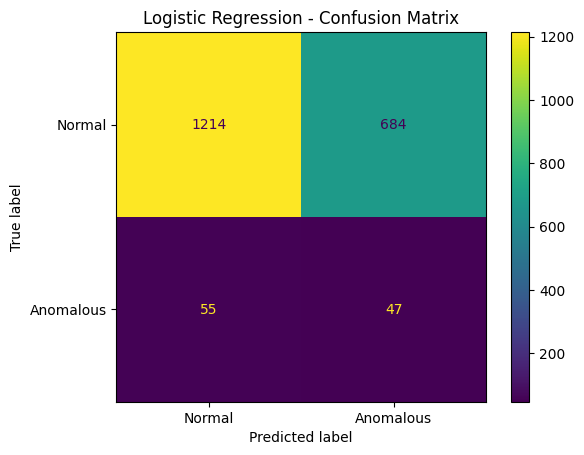

In [21]:
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalous"]
)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = logistic_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.5625


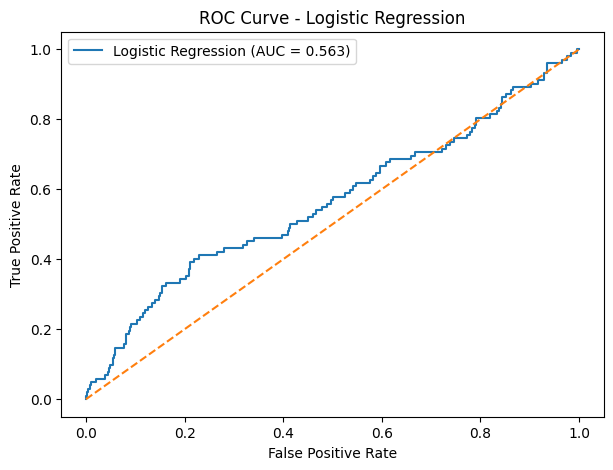

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [24]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}
logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.6305,
 'Precision': 0.06429548563611491,
 'Recall': 0.46078431372549017,
 'F1 Score': 0.11284513805522209,
 'ROC-AUC': 0.5625167875369326}

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            class_weight="balanced",
            random_state=42
        ))
    ]
)
print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [27]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [28]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated!")

Decision Tree predictions generated!


In [29]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree Results
--------------------
Accuracy : 0.704
Precision: 0.0687
Recall   : 0.3824
F1 Score : 0.1164


In [30]:
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", round(roc_auc_dt, 4))

Decision Tree ROC-AUC: 0.5791


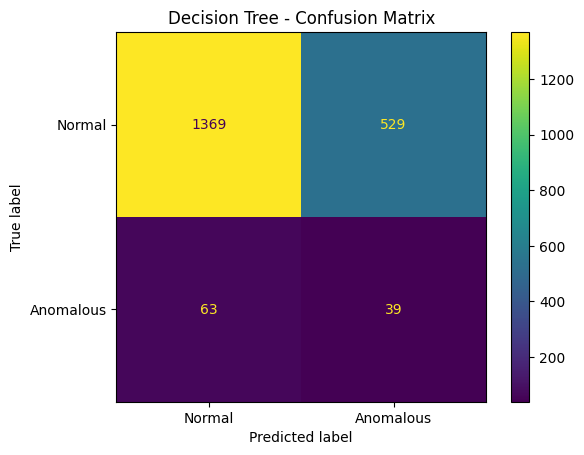

In [31]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Normal", "Anomalous"]
)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [32]:
decision_tree_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1 Score": f1_dt,
    "ROC-AUC": roc_auc_dt
}

decision_tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.704,
 'Precision': 0.06866197183098592,
 'Recall': 0.38235294117647056,
 'F1 Score': 0.11641791044776119,
 'ROC-AUC': 0.5791054567243125}

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)
print("Random Forest model created successfully!")

Random Forest model created successfully!


In [35]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [36]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [37]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest Results
--------------------
Accuracy : 0.8715
Precision: 0.0765
Recall   : 0.1373
F1 Score : 0.0982


In [38]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(roc_auc_rf, 4))

Random Forest ROC-AUC: 0.5353


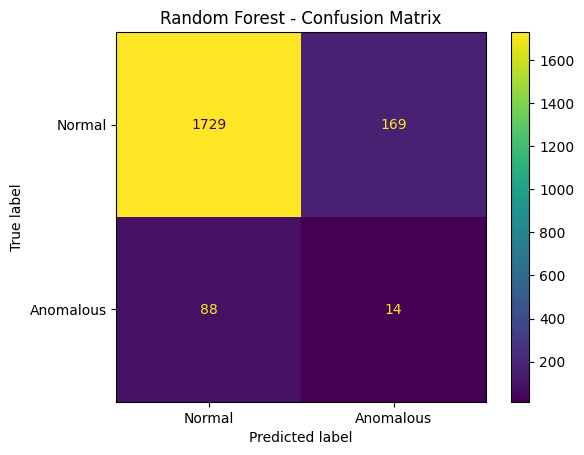

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Anomalous"]
)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [40]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf,
    "ROC-AUC": roc_auc_rf
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.8715,
 'Precision': 0.07650273224043716,
 'Recall': 0.13725490196078433,
 'F1 Score': 0.09824561403508772,
 'ROC-AUC': 0.5353158123101717}

In [41]:
model_comparison = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6305,0.064295,0.460784,0.112845,0.562517
1,Decision Tree,0.7040,0.068662,0.382353,0.116418,0.579105
2,Random Forest,0.8715,0.076503,0.137255,0.098246,0.535316


In [42]:
model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6305,0.0643,0.4608,0.1128,0.5625
1,Decision Tree,0.7040,0.0687,0.3824,0.1164,0.5791
2,Random Forest,0.8715,0.0765,0.1373,0.0982,0.5353


In [43]:
from sklearn.metrics import classification_report

print("Logistic Regression - Classification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Anomalous"]
))

Logistic Regression - Classification Report
              precision    recall  f1-score   support

      Normal       0.96      0.64      0.77      1898
   Anomalous       0.06      0.46      0.11       102

    accuracy                           0.63      2000
   macro avg       0.51      0.55      0.44      2000
weighted avg       0.91      0.63      0.73      2000



In [44]:
cm_logistic = confusion_matrix(y_test, y_pred)
print("Logistic Regression Confusion Matrix:")
print(cm_logistic)
tn, fp, fn, tp = cm_logistic.ravel()
print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Logistic Regression Confusion Matrix:
[[1214  684]
 [  55   47]]

True Negatives : 1214
False Positives: 684
False Negatives: 55
True Positives : 47


In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score
y_prob = logistic_model.predict_proba(X_test)[:, 1]
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })
threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.0510,1.0000,0.0971
1,0.15,0.0510,1.0000,0.0971
2,0.20,0.0511,1.0000,0.0971
3,0.25,0.0509,0.9902,0.0967
4,0.30,0.0512,0.9706,0.0972
5,0.35,0.0512,0.8922,0.0968
6,0.40,0.0504,0.7255,0.0943
7,0.45,0.0571,0.6176,0.1045
8,0.50,0.0643,0.4608,0.1128


In [46]:
threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.0510,1.0000,0.0971
1,0.15,0.0510,1.0000,0.0971
2,0.20,0.0511,1.0000,0.0971
3,0.25,0.0509,0.9902,0.0967
4,0.30,0.0512,0.9706,0.0972
5,0.35,0.0512,0.8922,0.0968
6,0.40,0.0504,0.7255,0.0943
7,0.45,0.0571,0.6176,0.1045
8,0.50,0.0643,0.4608,0.1128


In [47]:
feature_analysis = df.groupby("is_anomaly")[
    [
        "amount",
        "hours_since_prev_txn",
        "transaction_frequency_24h",
        "avg_amount_30d",
        "account_age_days",
        "distance_from_home_km",
        "new_device",
        "amount_ratio",
        "country_changed",
        "high_frequency",
        "transaction_hour"
    ]
].mean()
feature_analysis.round(2)

,amount,hours_since_prev_txn,transaction_frequency_24h,avg_amount_30d,account_age_days,distance_from_home_km,new_device,amount_ratio,country_changed,high_frequency,transaction_hour
is_anomaly,,,,,,,,,,,
0,48.63,17.92,2.18,44.47,1248.55,34.33,0.09,1.07,0.07,0.07,11.53
1,51.63,17.56,2.25,42.60,1324.30,37.29,0.18,1.18,0.14,0.07,12.09


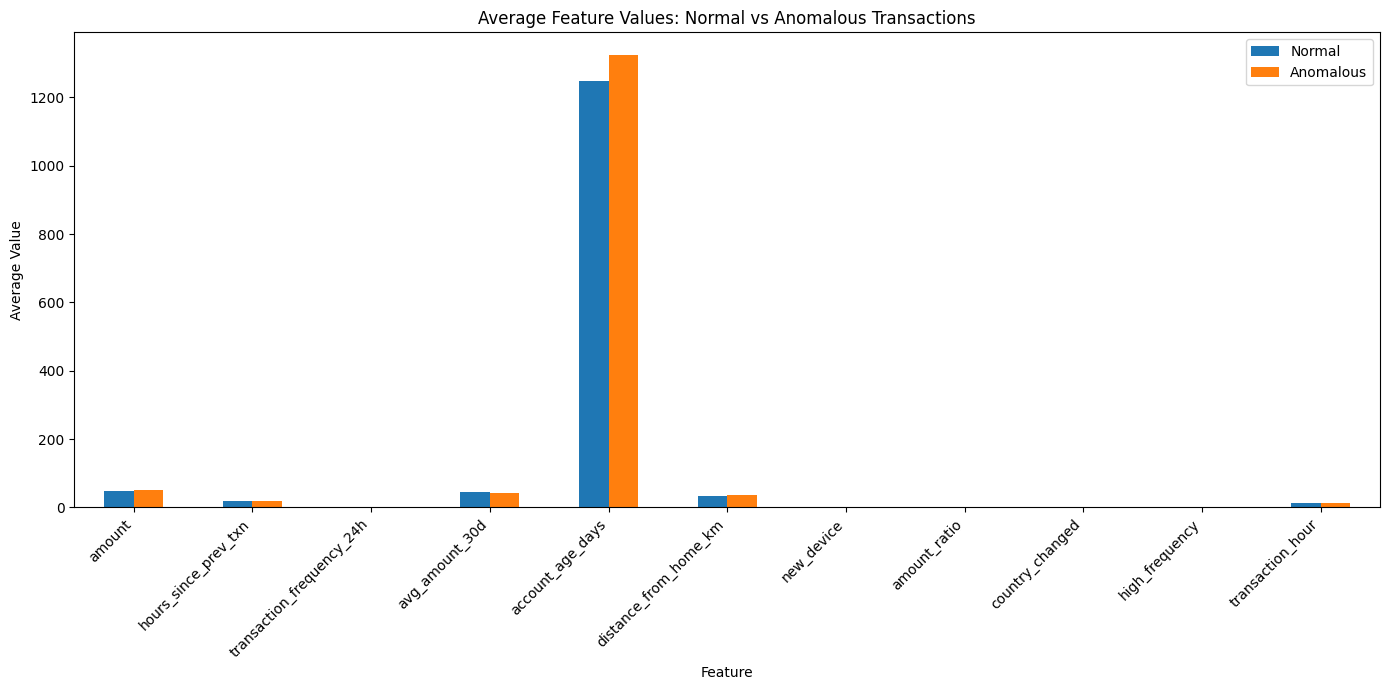

In [48]:
feature_analysis.T.plot(kind="bar", figsize=(14, 7))

plt.title("Average Feature Values: Normal vs Anomalous Transactions")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.legend(["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
comparison = df.groupby("is_anomaly")[
    [
        "amount",
        "hours_since_prev_txn",
        "transaction_frequency_24h",
        "avg_amount_30d",
        "account_age_days",
        "distance_from_home_km",
        "new_device",
        "amount_ratio",
        "country_changed",
        "high_frequency",
        "transaction_hour"
    ]
].mean().T

comparison.columns = ["Normal", "Anomalous"]

comparison["Difference_%"] = (
    (comparison["Anomalous"] - comparison["Normal"])
    / comparison["Normal"].replace(0, np.nan)
) * 100
comparison.round(2)

,Normal,Anomalous,Difference_%
amount,48.63,51.63,6.16
hours_since_prev_txn,17.92,17.56,-2.00
transaction_frequency_24h,2.18,2.25,3.20
avg_amount_30d,44.47,42.60,-4.20
account_age_days,1248.55,1324.30,6.07
distance_from_home_km,34.33,37.29,8.62
new_device,0.09,0.18,88.59
amount_ratio,1.07,1.18,9.43
country_changed,0.07,0.14,92.03
high_frequency,0.07,0.07,0.51


In [51]:
numeric_df = df.select_dtypes(include=np.number)

correlation_with_target = (
    numeric_df.corr()["is_anomaly"]
    .drop("is_anomaly")
    .sort_values(key=abs, ascending=False)
)

correlation_with_target.round(3)

new_device                   0.061
country_changed              0.055
amount_ratio                 0.041
account_age_days             0.023
distance_from_home_km        0.019
transaction_hour             0.018
amount                       0.016
avg_amount_30d              -0.015
transaction_frequency_24h    0.010
transaction_month            0.010
user_id                     -0.007
hours_since_prev_txn        -0.004
day_of_week                 -0.001
high_frequency               0.000
Name: is_anomaly, dtype: float64

In [52]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
importances = random_forest_model.named_steps["classifier"].feature_importances_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)
feature_importance.head(15)

,Feature,Importance
7,num__amount_ratio,0.109733
5,num__distance_from_home_km,0.097611
0,num__amount,0.097335
1,num__hours_since_prev_txn,0.092138
3,num__avg_amount_30d,0.091686
4,num__account_age_days,0.088647
10,num__transaction_hour,0.063195
12,num__transaction_month,0.044823
6,num__new_device,0.043684
8,num__country_changed,0.042776


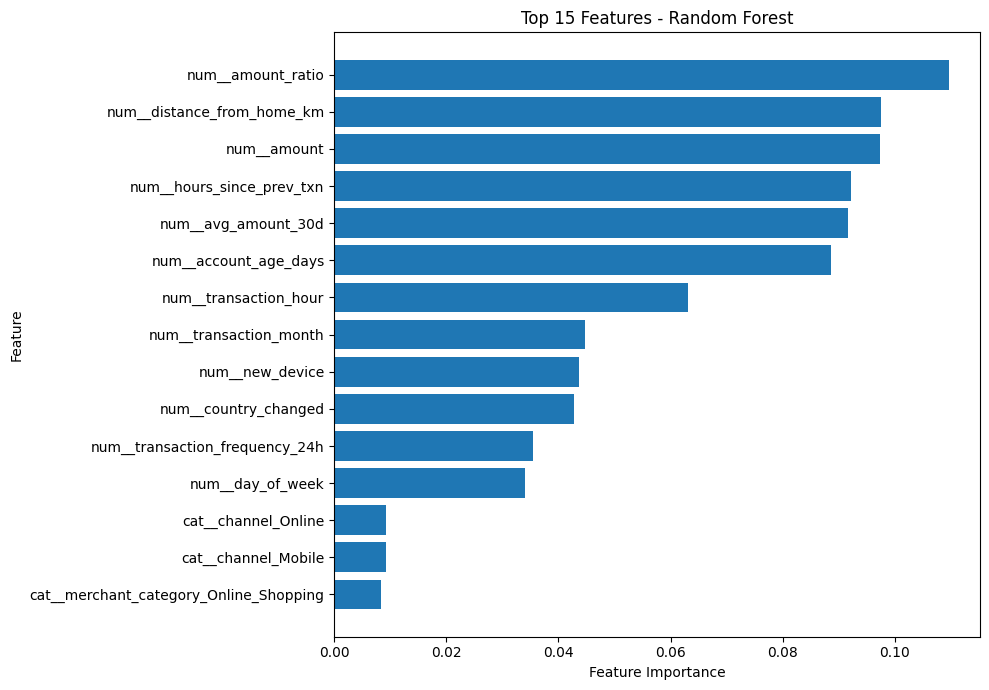

In [53]:
top_features = feature_importance.head(15).sort_values("Importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier
random_forest_unweighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ]
)
random_forest_unweighted.fit(X_train, y_train)
y_pred_rf_unweighted = random_forest_unweighted.predict(X_test)
accuracy_rf_unweighted = accuracy_score(y_test, y_pred_rf_unweighted)
precision_rf_unweighted = precision_score(
    y_test, y_pred_rf_unweighted, zero_division=0
)
recall_rf_unweighted = recall_score(
    y_test, y_pred_rf_unweighted, zero_division=0
)
f1_rf_unweighted = f1_score(
    y_test, y_pred_rf_unweighted, zero_division=0
)
y_prob_rf_unweighted = (
    random_forest_unweighted.predict_proba(X_test)[:, 1]
)
roc_auc_rf_unweighted = roc_auc_score(
    y_test, y_prob_rf_unweighted
)
print("Random Forest - Without Class Weight")
print("-------------------------------------")
print("Accuracy :", round(accuracy_rf_unweighted, 4))
print("Precision:", round(precision_rf_unweighted, 4))
print("Recall   :", round(recall_rf_unweighted, 4))
print("F1 Score :", round(f1_rf_unweighted, 4))
print("ROC-AUC  :", round(roc_auc_rf_unweighted, 4))

Random Forest - Without Class Weight
-------------------------------------
Accuracy : 0.949
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5737


In [55]:
rf_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
rf_threshold_results = []
for threshold in rf_thresholds:
    y_pred_threshold = (
        y_prob_rf_unweighted >= threshold
    ).astype(int)

    rf_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })
rf_threshold_df = pd.DataFrame(rf_threshold_results)
rf_threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.05,0.0689,0.4706,0.1202
1,0.10,0.0575,0.0490,0.0529
2,0.15,0.0588,0.0098,0.0168
3,0.20,0.3333,0.0098,0.0190
4,0.25,1.0000,0.0098,0.0194
5,0.30,0.0000,0.0000,0.0000
6,0.35,0.0000,0.0000,0.0000
7,0.40,0.0000,0.0000,0.0000
8,0.45,0.0000,0.0000,0.0000
9,0.50,0.0000,0.0000,0.0000


In [56]:
best_rf_threshold = rf_threshold_df.loc[
    rf_threshold_df["F1 Score"].idxmax()
]

print("Best Threshold:", best_rf_threshold["Threshold"])
print("Precision:", round(best_rf_threshold["Precision"], 4))
print("Recall:", round(best_rf_threshold["Recall"], 4))
print("F1 Score:", round(best_rf_threshold["F1 Score"], 4))

Best Threshold: 0.05
Precision: 0.0689
Recall: 0.4706
F1 Score: 0.1202


In [57]:
from sklearn.model_selection import train_test_split
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)
print("Training set:", X_train_new.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (6400, 17)
Validation set: (1600, 17)
Test set: (2000, 17)


In [58]:
rf_validation_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_validation_model.fit(X_train_new, y_train_new)
y_val_prob = rf_validation_model.predict_proba(X_val)[:, 1]

print("Random Forest trained successfully.")
print("Validation probabilities generated.")

Random Forest trained successfully.
Validation probabilities generated.


In [59]:
validation_thresholds = [
    0.10, 0.15, 0.20, 0.25, 0.30,
    0.35, 0.40, 0.45, 0.50
]
validation_results = []
for threshold in validation_thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })
validation_df = pd.DataFrame(validation_results)
validation_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.0512,1.0000,0.0975
1,0.15,0.0512,1.0000,0.0975
2,0.20,0.0512,1.0000,0.0975
3,0.25,0.0515,0.9878,0.0979
4,0.30,0.0523,0.9268,0.0990
5,0.35,0.0519,0.7195,0.0969
6,0.40,0.0504,0.4512,0.0907
7,0.45,0.0590,0.2561,0.0959
8,0.50,0.0853,0.1341,0.1043


In [60]:
best_validation = validation_df.loc[
    validation_df["F1 Score"].idxmax()
]

print("Selected Threshold:", best_validation["Threshold"])
print("Validation Precision:", round(best_validation["Precision"], 4))
print("Validation Recall:", round(best_validation["Recall"], 4))
print("Validation F1:", round(best_validation["F1 Score"], 4))

Selected Threshold: 0.5
Validation Precision: 0.0853
Validation Recall: 0.1341
Validation F1: 0.1043


In [61]:
print("Selected Threshold:", best_validation["Threshold"])
print("Validation Precision:", round(best_validation["Precision"], 4))
print("Validation Recall:", round(best_validation["Recall"], 4))
print("Validation F1:", round(best_validation["F1 Score"], 4))

Selected Threshold: 0.5
Validation Precision: 0.0853
Validation Recall: 0.1341
Validation F1: 0.1043


In [62]:
selected_threshold = best_validation["Threshold"]
y_test_prob_final = rf_validation_model.predict_proba(X_test)[:, 1]
y_test_final = (
    y_test_prob_final >= selected_threshold
).astype(int)
final_accuracy = accuracy_score(y_test, y_test_final)
final_precision = precision_score(
    y_test, y_test_final, zero_division=0
)
final_recall = recall_score(
    y_test, y_test_final, zero_division=0
)
final_f1 = f1_score(
    y_test, y_test_final, zero_division=0
)
final_roc_auc = roc_auc_score(
    y_test, y_test_prob_final
)
print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("Selected Threshold:", selected_threshold)
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_roc_auc, 4))

FINAL MODEL PERFORMANCE
-----------------------
Selected Threshold: 0.5
Accuracy : 0.882
Precision: 0.0813
Recall   : 0.1275
F1 Score : 0.0992
ROC-AUC  : 0.5406


In [63]:
cm_final = confusion_matrix(y_test, y_test_final)
print("Final Confusion Matrix:")
print(cm_final)
tn, fp, fn, tp = cm_final.ravel()
print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Final Confusion Matrix:
[[1751  147]
 [  89   13]]

True Negatives : 1751
False Positives: 147
False Negatives: 89
True Positives : 13


In [64]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)
final_model.fit(X_train, y_train)
print("Final deployment model trained successfully!")

Final deployment model trained successfully!


In [65]:
import joblib

joblib.dump(final_model, "payment_anomaly_model.pkl")

print("Model saved as payment_anomaly_model.pkl")

Model saved as payment_anomaly_model.pkl


In [66]:
import os

print(os.path.exists("payment_anomaly_model.pkl"))
print(os.path.abspath("payment_anomaly_model.pkl"))

True
C:\Users\Anamika Chauhan\payment_anomaly_model.pkl


In [68]:
import joblib

loaded_model = joblib.load("payment_anomaly_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [69]:
sample_transaction = pd.DataFrame([{
    "amount": 2500,
    "merchant_category": "Online Shopping",
    "country": "India",
    "home_country": "India",
    "channel": "Online",
    "hours_since_prev_txn": 5,
    "transaction_frequency_24h": 2,
    "avg_amount_30d": 1500,
    "account_age_days": 500,
    "distance_from_home_km": 10,
    "new_device": 0,
    "amount_ratio": 2500 / (1500 + 1),
    "country_changed": 0,
    "high_frequency": 0,
    "transaction_hour": 14,
    "day_of_week": 2,
    "transaction_month": 9
}])

sample_transaction

,amount,merchant_category,country,home_country,channel,hours_since_prev_txn,transaction_frequency_24h,avg_amount_30d,account_age_days,distance_from_home_km,new_device,amount_ratio,country_changed,high_frequency,transaction_hour,day_of_week,transaction_month
0,2500,Online Shopping,India,India,Online,5,2,1500,500,10,0,1.665556,0,0,14,2,9


In [70]:
prediction = loaded_model.predict(sample_transaction)

probability = loaded_model.predict_proba(sample_transaction)[0][1]

print("Prediction:", prediction[0])
print("Anomaly Probability:", round(probability, 4))

Prediction: 0
Anomaly Probability: 0.3579


In [71]:
import os
print(os.getcwd())

C:\Users\Anamika Chauhan


In [72]:
%%writefile app.py

print("Payment Transaction Anomaly Detection App")

Writing app.py


In [73]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
model = joblib.load("payment_anomaly_model.pkl")
st.set_page_config(
    page_title="Payment Transaction Anomaly Detection",
    page_icon="💳",
    layout="centered"
)
st.title("💳 Payment Transaction Anomaly Detection")
st.write("Enter the transaction details below to check whether the transaction is normal or anomalous.")
st.divider()
amount = st.number_input(
    "Transaction Amount",
    min_value=0.0,
    value=2500.0
)
merchant_category = st.selectbox(
    "Merchant Category",
    ["Online Shopping", "Grocery", "Travel", "Restaurant", "Electronics"]
)
country = st.selectbox(
    "Transaction Country",
    ["India", "USA", "UK", "UAE", "Singapore"]
)
home_country = st.selectbox(
    "Home Country",
    ["India", "USA", "UK", "UAE", "Singapore"]
)
channel = st.selectbox(
    "Transaction Channel",
    ["Online", "Mobile", "POS"]
)
hours_since_prev_txn = st.number_input(
    "Hours Since Previous Transaction",
    min_value=0.0,
    value=5.0
)
transaction_frequency_24h = st.number_input(
    "Transaction Frequency in Last 24 Hours",
    min_value=0,
    value=2
)

avg_amount_30d = st.number_input(
    "Average Transaction Amount (30 Days)",
    min_value=0.0,
    value=1500.0
)
account_age_days = st.number_input(
    "Account Age (Days)",
    min_value=0,
    value=500
)
distance_from_home_km = st.number_input(
    "Distance From Home (km)",
    min_value=0.0,
    value=10.0
)
new_device = st.selectbox(
    "Is This a New Device?",
    [0, 1]
)
transaction_hour = st.number_input(
    "Transaction Hour (0-23)",
    min_value=0,
    max_value=23,
    value=14
)
day_of_week = st.number_input(
    "Day of Week (0=Monday, 6=Sunday)",
    min_value=0,
    max_value=6,
    value=2
)
transaction_month = st.number_input(
    "Transaction Month",
    min_value=1,
    max_value=12,
    value=9
)
amount_ratio = amount / (avg_amount_30d + 1)
country_changed = int(country != home_country)
high_frequency = int(transaction_frequency_24h >= 5)
input_data = pd.DataFrame([{
    "amount": amount,
    "merchant_category": merchant_category,
    "country": country,
    "home_country": home_country,
    "channel": channel,
    "hours_since_prev_txn": hours_since_prev_txn,
    "transaction_frequency_24h": transaction_frequency_24h,
    "avg_amount_30d": avg_amount_30d,
    "account_age_days": account_age_days,
    "distance_from_home_km": distance_from_home_km,
    "new_device": new_device,
    "amount_ratio": amount_ratio,
    "country_changed": country_changed,
    "high_frequency": high_frequency,
    "transaction_hour": transaction_hour,
    "day_of_week": day_of_week,
    "transaction_month": transaction_month
}])
st.divider()
if st.button("🔍 Check Transaction"):

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("⚠️ Anomalous Transaction")
    else:
        st.success("✅ Normal Transaction")

    st.write(
        "Anomaly Probability:",
        f"{probability:.2%}"
    )

Overwriting app.py


In [74]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [75]:
!streamlit run app.py

'streamlit' is not recognized as an internal or external command,
operable program or batch file.


In [77]:
import sys
!{sys.executable} -m streamlit run app.py

'C:\Users\Anamika' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import os
import sys
os.system(f'"{sys.executable}" -m streamlit run app.py')

In [3]:
print("TEST SUCCESSFUL")

TEST SUCCESSFUL


In [5]:
import os

files = [
    "Payment_Transaction_Anomaly_Classification.ipynb",
    "payment_transaction_anomaly_dataset.csv",
    "payment_anomaly_model.pkl",
    "app.py",
    "requirements.txt",
    "README.md"
]

for file in files:
    print(file, "->", os.path.exists(file))

Payment_Transaction_Anomaly_Classification.ipynb -> True
payment_transaction_anomaly_dataset.csv -> True
payment_anomaly_model.pkl -> True
app.py -> True
requirements.txt -> True
README.md -> True
